# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 51     |  |
| :-------------|:-------------|
| Batu Sönmez| 6175163 |
| Victor Scholten| 6434789 |
| Taeke Beckers| 6329586 |

| Planning Groep: 51     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Criteria opgesteld | 12.30 |
| Mijlpaal 2: Eerste kalibratie meting gedaan| 15.00 |
| Pauze 1| 12.30-13.30 |
| Pauze 2| 15.30-16.00 |

## *Opdracht 1*: Foto van alle schetsen.

![Alt](ideesensor.jpeg "analyse: ideeen")
## *Opdracht 2*, MIJLPAAL, Leerdoel


| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Hall sensor | Sleutelhanger | Range: tussen 0 en 5 cm afstand sleutel(hanger)herkennen. |
|Hall sensor | Sleutelhanger | Resolutie: +/- 2 cm onzekerheid |
|Thermistor | Weerstand oververhitting check | Moet een resolutie hebben van 0 tot 300 graden Celsius. |
|Thermistor | Weerstand oververhitting check | Temperatuur onnauwkeurigheid +/- 3 graden. |
|Lichtsensor (LDR) | Lampje aan op moment dat er een gebrek aan licht is in de omgeving. | Verschil tussen schemering (10 lux) en nacht (1 lux) onderscheid kunnen maken met een onzekerheid van +/- 1 lux. |
|Lichtsensor (LDR) | Lampje aan op moment dat er een gebrek aan licht is in de omgeving. | Moet binnen een seconde kunnen werken met een onzekerheid van een halve seconde. |

Groep 51 heeft gekozen voor Hall sensor. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Op de foto is te zien dat we een simpele schakeling gebruiken: de Arduino is verbonden met drie draden op A0, 5V en GND, die allemaal zijn verbonden met een Hall sesnor. Daarna is dit langs een lineaal gezet (dat is geductaped op de tafel voor extra stabiliteit). Vervolgens wordt een magneet telkens dichterbij de sensor bewogen

 ![Alt](schets.jpeg "schets")

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? 
De variabele die wordt veranderd is de afstand tussen de magneet en (hall) sensor. Ook wordt de orientatie van de magneeet veranderd.

2. Over welk bereik ga je deze variabelen veranderen?
Het bereik die is gekozen is tussen de 0 en 8.0 cm met een stapgrootte van 0.5 cm.

3. Wat ga je allemaal meten?
Wat er wordt gemeten is wat voor verband er is tussen een gemeten waarde door een Arduino (die in Arduino IDE verschijnt) en het afstand tussen de magneet en de sensor.

4. Hoeveel metingen ga je doen?
2 metingen.

5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?
Deze keuzes en resultaten zouden voldoende moeten zijn om te kijken of de sensor geschikt is.


## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Zoals te zien in de foto is dit de meetopstelling. Links is het Arduino, die verbonden is met de pins 5 V, GND en A0. Deze zijn daarna verbonden met de Hall sensor. Vervolgens is de sensor op de tafel geplakt. Ook is de lineaal vastgeplakt aan de tafel. De Arduino krijgt zijn voeding van een laptop met behulp van een USB-C kabel. Op de laptop zelf, is via het programma Arduino IDE de meetwaarden bepaald. Ten slotte is er gebruik gemaakt van magneten, die langs de lineaal, steeds dichterbij de sensor zijn toebewogen.
 ![Alt](opstelling.jpeg "meetopstelling")

## *Opdracht 6*: Meten en fitten, Leerdoel

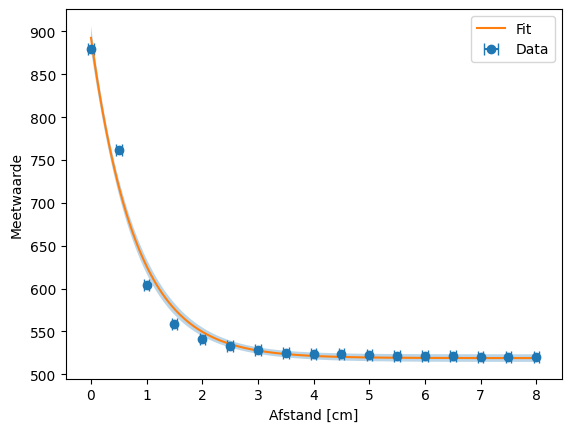

In [1]:
#importen van libraries
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#arrays voor meetwaardes
afstand = np.array([0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0]) #cm
meetwaarde3 = np.array([879, 762, 604, 559, 541, 533, 528, 525, 524, 523, 522, 521, 521, 521, 520.5, 520, 520]) #zonder afstand: meetwaarde = 519
meting4 = np.array([879, 730, 600, 560, 541, 532, 528, 525, 524, 523, 522, 521, 521, 520.5, 520, 520, 520])
meting5 = np.array([878, 720, 598, 558, 540, 532, 528, 525, 524, 522, 522, 521, 521, 520.5, 520, 520, 520])

#een exponentiele functie met een negatieve exponent wordt gedefinieerd.
def f(x, a, b , c):
    return c + a*np.exp(-b*(x))

#curve fit wordt toegepeast
#rede voor 519 in p0: laagste waarde van de meetwaarde = 519
popt, pcov = curve_fit(f, afstand, meetwaarde3, p0 = [2, 0, 519])
a_fit, b_fit, c_fit = popt
a_unc, b_unc, c_unc = np.sqrt(np.diag(pcov))


x_fit = np.linspace(afstand.min(), afstand.max(), 300)
y_fit = f(x_fit, *popt)

a_fit, b_fit, c_fit = popt


E = np.exp(-b_fit * x_fit)
J = np.column_stack([
    E,                    # dy/da
    -a_fit * x_fit * E,   # dy/db
    np.ones_like(x_fit)   # dy/dc
])

y_var = np.einsum('ij,jk,ik->i', J, pcov, J)   
y_err = np.sqrt(y_var)

# plot
plt.figure()
plt.errorbar(afstand, meetwaarde3, xerr=0.05, fmt='o', capsize=4, label='Data')  
plt.plot(x_fit, y_fit, label='Fit')
plt.fill_between(x_fit, y_fit - y_err, y_fit + y_err, alpha=0.3)
plt.xlabel('Afstand [cm]')
plt.ylabel('Meetwaarde')
plt.legend()
plt.show()






## *Opdracht 7*: Iteratie nodig?

Er was iteratie nodig om zeker te weten om het verband neer te leggen en te kijken of onze meetwaardes consistent waren. Er bleek dan ook uit dat onze metingen vrij consistent waren. We hebben 3 keer geitereerd.

## *Opdracht 8*: Conclusie, leerdoel
 
 De error is kleiner dan 2 cm en tot 5 cm is op basis van de meetwaarde duidelijk hoe ver de magneet zich van de sensor bevind. Als de magneet tussen 5-10cm is, wordt deze wel gedetecteerd ,maar is het niet duidelijk waar de magneet is binnen die range. De sensor voldoet dus aan de criteria die we hebben opgesteld.

## *Opdracht 9*: Aantonen leerdoelen beheersing


### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

![Alt](spanningsdeler.jpg "spanningsdeler")


![Alt](opstelling.jpeg "meetopstelling")

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

1. Welke variabelen ga je veranderen? 
De variabele die wordt veranderd is de afstand tussen de magneet en (hall) sensor. Ook wordt de orientatie van de magneeet veranderd.

2. Over welk bereik ga je deze variabelen veranderen?
Het bereik die is gekozen is tussen de 0 en 8.0 cm met een stapgrootte van 0.5 cm.

3. Wat ga je allemaal meten?
Wat er wordt gemeten is wat voor verband er is tussen een gemeten waarde door een Arduino (die in Arduino IDE verschijnt) en het afstand tussen de magneet en de sensor.

4. Hoeveel metingen ga je doen?
we zijn uitgekomen bij 3 metingen om de variatie in de waarden te kunnen bekijken.

5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?
Deze keuzes en resultaten zouden voldoende moeten zijn om te kijken of de sensor geschikt is.


### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Hall sensor | Sleutelhanger | Range: tussen 0 en 5 cm afstand sleutel(hanger)herkennen. |
|Hall sensor | Sleutelhanger | Resolutie: +/- 2 cm onzekerheid |
|Thermistor | Weerstand oververhitting check | Moet een resolutie hebben van 0 tot 300 graden Celsius. |
|Thermistor | Weerstand oververhitting check | Temperatuur onnauwkeurigheid +/- 3 graden. |
|Lichtsensor (LDR) | Lampje aan op moment dat er een gebrek aan licht is in de omgeving. | Verschil tussen schemering (10 lux) en nacht (1 lux) onderscheid kunnen maken met een onzekerheid van +/- 1 lux. |
|Lichtsensor (LDR) | Lampje aan op moment dat er een gebrek aan licht is in de omgeving. | Moet binnen een seconde kunnen werken met een onzekerheid van een halve seconde. |

Groep 51 heeft gekozen voor Hall sensor. 


 ![Alt](fit.png "schets student")


